# Hybrid Counterfactual Clinical Decision Support using Temporal Transformers on EHR Data

This notebook combines the stronger parts of both uploaded notebooks:

- **Temporal Transformer + treatment embedding** for patient-level mortality risk prediction.
- **Multi-treatment counterfactual heads** for treatment-specific what-if risk.
- **Propensity head** for treatment assignment prediction.
- **Hybrid loss** = mortality loss + treatment-head factual loss + propensity loss.

> Important: this is a model-based counterfactual simulation, not a proven causal treatment effect estimate.

## 1. Imports and setup

In [1]:
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


## 2. Load MIMIC-IV demo data

In [2]:
# For Google Colab
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/mimic-iv-clinical-database-demo-2.2'

# Increase these if your RAM allows it. None = load full file.
LAB_NROWS = 50000
CHART_NROWS = 50000
PRESCRIPTION_NROWS = 20000

patients = pd.read_csv(f"{base_path}/hosp/patients.csv.gz", compression='gzip')
admissions = pd.read_csv(
    f"{base_path}/hosp/admissions.csv.gz",
    compression='gzip',
    parse_dates=['admittime', 'dischtime']
)
icustays = pd.read_csv(
    f"{base_path}/icu/icustays.csv.gz",
    compression='gzip',
    parse_dates=['intime', 'outtime']
)

labevents = pd.read_csv(
    f"{base_path}/hosp/labevents.csv.gz",
    compression='gzip',
    nrows=LAB_NROWS,
    parse_dates=['charttime']
)

chartevents = pd.read_csv(
    f"{base_path}/icu/chartevents.csv.gz",
    compression='gzip',
    nrows=CHART_NROWS,
    parse_dates=['charttime']
)

try:
    prescriptions = pd.read_csv(
        f"{base_path}/hosp/prescriptions.csv.gz",
        compression='gzip',
        nrows=PRESCRIPTION_NROWS
    )
except FileNotFoundError:
    prescriptions = None
    print("prescriptions.csv.gz not found; treatment will fall back to admission_type")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)
print("Lab events:", labevents.shape)
print("Chart events:", chartevents.shape)
print("Prescriptions:", None if prescriptions is None else prescriptions.shape)

Mounted at /content/drive
Patients: (100, 6)
Admissions: (275, 16)
ICU stays: (140, 8)
Lab events: (50000, 16)
Chart events: (50000, 11)
Prescriptions: (18087, 21)


## 3. Base table and treatment proxy

In [11]:
patients_base = patients[['subject_id', 'gender', 'anchor_age']].drop_duplicates('subject_id')

admissions_base = admissions[[
    'subject_id', 'hadm_id', 'admittime', 'dischtime',
    'hospital_expire_flag', 'admission_type'
]].drop_duplicates(['subject_id', 'hadm_id'])

icustays_base = icustays[[
    'subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime'
]].drop_duplicates('stay_id')

df = icustays_base.merge(admissions_base, on=['subject_id', 'hadm_id'], how='left')
df = df.merge(patients_base, on='subject_id', how='left')

# Length of stay features
df['hospital_los'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 86400
df['icu_los'] = (df['outtime'] - df['intime']).dt.total_seconds() / 86400

# Outcome and demographics
df['mortality'] = df['hospital_expire_flag'].fillna(0).astype(int)
df['outcome'] = df['mortality']

df['gender'] = df['gender'].map({'M': 1, 'F': 0}).fillna(-1).astype(int)

for col in ['anchor_age', 'hospital_los', 'icu_los']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = df[col].clip(lower=0)

df['admission_type'] = df['admission_type'].fillna('UNKNOWN')

# Treatment proxy: prefer prescription drug labels, otherwise admission_type
if prescriptions is not None and {'subject_id', 'hadm_id'}.issubset(prescriptions.columns):

    drug_col = None
    for candidate in ['drug', 'drug_type', 'formulary_drug_cd']:
        if candidate in prescriptions.columns:
            drug_col = candidate
            break

    if drug_col is not None:
        rx = prescriptions[['subject_id', 'hadm_id', drug_col]].dropna().copy()
        rx[drug_col] = rx[drug_col].astype(str).str.upper().str.strip()

        top_drugs = rx[drug_col].value_counts().head(10).index
        rx['treatment_label'] = np.where(
            rx[drug_col].isin(top_drugs),
            rx[drug_col],
            'OTHER_DRUG'
        )

        rx_mode = (
            rx.groupby(['subject_id', 'hadm_id'])['treatment_label']
              .agg(lambda s: s.value_counts().index[0])
              .reset_index()
        )

        df = df.merge(rx_mode, on=['subject_id', 'hadm_id'], how='left')
        df['treatment_label'] = df['treatment_label'].fillna('NO_PRESCRIPTION')

        treatment_source = f"prescriptions.{drug_col} top-10 proxy"

    else:
        df['treatment_label'] = df['admission_type'].astype(str)
        treatment_source = 'admission_type fallback; no usable prescription drug column'

else:
    df['treatment_label'] = df['admission_type'].astype(str)
    treatment_source = 'admission_type fallback; prescriptions unavailable'

PAD_TREATMENT_ID = 0

treatment_categories = sorted(df['treatment_label'].astype(str).unique())

treatment_to_id = {
    name: i + 1
    for i, name in enumerate(treatment_categories)
}

treatment_mapping = {
    i: name
    for name, i in treatment_to_id.items()
}

treatment_mapping[PAD_TREATMENT_ID] = 'PAD'

df['treatment'] = df['treatment_label'].map(treatment_to_id).astype(int)

print("Base dataset:", df.shape)
print("Treatment source:", treatment_source)
print("Number of treatment categories:", len(treatment_categories))
print("Treatment mapping:", treatment_mapping)

print("Outcome distribution:")
print(df['outcome'].value_counts(dropna=False))

Base dataset: (140, 17)
Treatment source: prescriptions.drug top-10 proxy
Number of treatment categories: 3
Treatment mapping: {1: 'INSULIN', 2: 'NO_PRESCRIPTION', 3: 'OTHER_DRUG', 0: 'PAD'}
Outcome distribution:
outcome
0    120
1     20
Name: count, dtype: int64


## 4. Feature engineering and patient sequences

In [13]:
# Lab-event features
lab_cols = ['subject_id', 'hadm_id', 'itemid', 'valuenum']

lab = labevents[
    [c for c in lab_cols if c in labevents.columns]
].dropna(subset=['subject_id', 'hadm_id', 'valuenum']).copy()

if 'itemid' in lab.columns and len(lab) > 0:
    item_stats = (
        lab.groupby('itemid')['valuenum']
        .agg(['mean', 'std'])
        .rename(columns={'mean': 'item_mean', 'std': 'item_std'})
    )

    lab = lab.merge(item_stats, on='itemid', how='left')
    lab['item_std'] = lab['item_std'].replace(0, np.nan)

    lab['abnormal_flag'] = (
        (lab['valuenum'] - lab['item_mean']).abs() > lab['item_std']
    ).fillna(False).astype(int)

else:
    lab['abnormal_flag'] = 0

lab_agg = (
    lab.groupby(['subject_id', 'hadm_id'])
    .agg(
        Total_lab_events=('valuenum', 'count'),
        Abnormal_counts=('abnormal_flag', 'sum'),
        mean_lab_value=('valuenum', 'mean'),
        std_lab_value=('valuenum', 'std')
    )
    .reset_index()
)

lab_agg['Normal_counts'] = (
    lab_agg['Total_lab_events'] - lab_agg['Abnormal_counts']
)

lab_agg['abnormal_rate'] = (
    lab_agg['Abnormal_counts'] / lab_agg['Total_lab_events'].clip(lower=1)
)

# Chart-event/vital summary features
chart_cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'valuenum']

chart = chartevents[
    [c for c in chart_cols if c in chartevents.columns]
].dropna(subset=['valuenum']).copy()

chart_group_cols = (
    ['subject_id', 'hadm_id']
    if {'subject_id', 'hadm_id'}.issubset(chart.columns)
    else ['stay_id']
)

if len(chart) > 0:
    chart_agg = (
        chart.groupby(chart_group_cols)
        .agg(
            Total_chart_events=('valuenum', 'count'),
            mean_chart_value=('valuenum', 'mean'),
            std_chart_value=('valuenum', 'std'),
            min_chart_value=('valuenum', 'min'),
            max_chart_value=('valuenum', 'max')
        )
        .reset_index()
    )
else:
    chart_agg = pd.DataFrame(
        columns=chart_group_cols + [
            'Total_chart_events',
            'mean_chart_value',
            'std_chart_value',
            'min_chart_value',
            'max_chart_value'
        ]
    )

feature_drop_cols = [
    'Total_lab_events',
    'Abnormal_counts',
    'Normal_counts',
    'abnormal_rate',
    'mean_lab_value',
    'std_lab_value',
    'Total_chart_events',
    'mean_chart_value',
    'std_chart_value',
    'min_chart_value',
    'max_chart_value'
]

df = df.drop(
    columns=[c for c in feature_drop_cols if c in df.columns],
    errors='ignore'
)

df = df.merge(lab_agg, on=['subject_id', 'hadm_id'], how='left')
df = df.merge(chart_agg, on=chart_group_cols, how='left')

df = df.fillna(0)

feature_cols = [
    'anchor_age',
    'gender',
    'hospital_los',
    'icu_los',
    'Normal_counts',
    'Abnormal_counts',
    'Total_lab_events',
    'abnormal_rate',
    'mean_lab_value',
    'std_lab_value',
    'Total_chart_events',
    'mean_chart_value',
    'std_chart_value',
    'min_chart_value',
    'max_chart_value'
]

X_list, T_list, y_list, patient_ids = [], [], [], []

for pid, group in df.groupby('subject_id'):
    group = group.sort_values('admittime')

    X_list.append(group[feature_cols].astype(float).values)
    T_list.append(group['treatment'].astype(int).values)
    y_list.append(float(group['outcome'].max()))
    patient_ids.append(pid)

X = np.array(X_list, dtype=object)
T = np.array(T_list, dtype=object)
y = np.array(y_list, dtype=np.float32)
patient_ids = np.array(patient_ids)

print("Total patients:", len(X))
print("Feature columns:", feature_cols)
print("Example sequence shape:", X[0].shape)

print("Patient-level outcome distribution:")
print(pd.Series(y).value_counts())

Total patients: 100
Feature columns: ['anchor_age', 'gender', 'hospital_los', 'icu_los', 'Normal_counts', 'Abnormal_counts', 'Total_lab_events', 'abnormal_rate', 'mean_lab_value', 'std_lab_value', 'Total_chart_events', 'mean_chart_value', 'std_chart_value', 'min_chart_value', 'max_chart_value']
Example sequence shape: (1, 15)
Patient-level outcome distribution:
0.0    85
1.0    15
Name: count, dtype: int64


## 5. Padding, split, and scaling

In [14]:
def pad_3d_sequences(sequences, value=0.0, dtype=np.float32):
    max_len = max(len(seq) for seq in sequences)
    num_features = sequences[0].shape[1]
    out = np.full((len(sequences), max_len, num_features), value, dtype=dtype)
    mask = np.zeros((len(sequences), max_len), dtype=np.float32)
    for i, seq in enumerate(sequences):
        length = len(seq)
        out[i, :length, :] = seq
        mask[i, :length] = 1.0
    return out, mask

def pad_2d_sequences(sequences, value=PAD_TREATMENT_ID, dtype=np.int64):
    max_len = max(len(seq) for seq in sequences)
    out = np.full((len(sequences), max_len), value, dtype=dtype)
    for i, seq in enumerate(sequences):
        out[i, :len(seq)] = seq
    return out

X_padded, mask_padded = pad_3d_sequences(X)
T_padded = pad_2d_sequences(T)

X_train, X_test, T_train, T_test, mask_train, mask_test, y_train, y_test, pid_train, pid_test = train_test_split(
    X_padded, T_padded, mask_padded, y, patient_ids,
    test_size=0.2,
    random_state=42,
    stratify=y if len(np.unique(y)) > 1 and min(np.bincount(y.astype(int))) >= 2 else None
)

N_train, S, F = X_train.shape
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, F)
X_test_2d = X_test.reshape(-1, F)

train_valid = mask_train.reshape(-1) == 1
test_valid = mask_test.reshape(-1) == 1

X_train_2d[train_valid] = scaler.fit_transform(X_train_2d[train_valid])
X_test_2d[test_valid] = scaler.transform(X_test_2d[test_valid])

# Keep padding exactly zero.
X_train_2d[~train_valid] = 0.0
X_test_2d[~test_valid] = 0.0

X_train = X_train_2d.reshape(X_train.shape).astype(np.float32)
X_test = X_test_2d.reshape(X_test.shape).astype(np.float32)

print("X padded:", X_padded.shape)
print("T padded:", T_padded.shape)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

X padded: (100, 5, 15)
T padded: (100, 5)
Train: (80, 5, 15) (80,)
Test: (20, 5, 15) (20,)


## 6. Dataset and dataloaders

In [15]:
class EHRTreatmentDataset(Dataset):
    def __init__(self, X, T, mask, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.T = torch.tensor(T, dtype=torch.long)
        self.mask = torch.tensor(mask, dtype=torch.bool)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.T[idx], self.mask[idx], self.y[idx]

train_dataset = EHRTreatmentDataset(X_train, T_train, mask_train, y_train)
test_dataset = EHRTreatmentDataset(X_test, T_test, mask_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

batch_X, batch_T, batch_mask, batch_y = next(iter(train_loader))
print("X batch:", batch_X.shape)
print("T batch:", batch_T.shape)
print("Mask batch:", batch_mask.shape)
print("y batch:", batch_y.shape)

X batch: torch.Size([64, 5, 15])
T batch: torch.Size([64, 5])
Mask batch: torch.Size([64, 5])
y batch: torch.Size([64])


## 7. Hybrid model: Transformer + mortality head + treatment heads + propensity head

In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class HybridCounterfactualTemporalTransformer(nn.Module):
    def __init__(self, num_features, num_treatments, d_model=64, nhead=4, num_layers=2, dropout=0.2, padding_idx=0):
        super().__init__()
        self.num_treatments = num_treatments
        self.padding_idx = padding_idx

        self.feature_proj = nn.Linear(num_features, d_model)
        self.treatment_embed = nn.Embedding(num_treatments, d_model, padding_idx=padding_idx)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.shared = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Main factual mortality classifier
        self.mortality_head = nn.Linear(d_model, 1)

        # Treatment-specific mortality heads. Index 0 is PAD/baseline and is ignored in factual treatment-head loss.
        self.treatment_heads = nn.ModuleList([
            nn.Linear(d_model, 1) for _ in range(num_treatments)
        ])

        # Propensity head predicts latest/last real treatment class.
        self.propensity_head = nn.Linear(d_model, num_treatments)

    def encode(self, x, treatment_seq, valid_mask):
        padding_mask = ~valid_mask
        h = self.feature_proj(x) + self.treatment_embed(treatment_seq)
        h = self.pos_encoder(h)
        h = self.transformer(h, src_key_padding_mask=padding_mask)

        valid_mask_f = valid_mask.unsqueeze(-1).float()
        pooled = (h * valid_mask_f).sum(dim=1) / valid_mask_f.sum(dim=1).clamp(min=1)
        return self.shared(pooled)

    def forward(self, x, treatment_seq, valid_mask):
        rep = self.encode(x, treatment_seq, valid_mask)
        mortality_logit = self.mortality_head(rep).squeeze(-1)
        treatment_logits = torch.stack([head(rep).squeeze(-1) for head in self.treatment_heads], dim=1)
        propensity_logits = self.propensity_head(rep)
        return mortality_logit, treatment_logits, propensity_logits, rep


def get_last_real_treatment(treatment_seq, valid_mask):
    lengths = valid_mask.long().sum(dim=1).clamp(min=1)
    idx = lengths - 1
    return treatment_seq[torch.arange(treatment_seq.size(0), device=treatment_seq.device), idx]

## 8. Initialize model and hybrid loss

In [17]:
num_features = X_train.shape[-1]
num_treatments = int(max(T_train.max(), T_test.max())) + 1  # includes PAD=0

model = HybridCounterfactualTemporalTransformer(
    num_features=num_features,
    num_treatments=num_treatments,
    d_model=64,
    nhead=4,
    num_layers=2,
    dropout=0.2,
    padding_idx=PAD_TREATMENT_ID
).to(device)

num_pos = float((y_train == 1).sum())
num_neg = float((y_train == 0).sum())
pos_weight_value = num_neg / max(num_pos, 1.0)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)

mortality_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
treatment_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
propensity_criterion = nn.CrossEntropyLoss(ignore_index=PAD_TREATMENT_ID)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Tune these if one objective dominates.
ALPHA_TREATMENT = 0.5
BETA_PROPENSITY = 0.2

def hybrid_loss_fn(mortality_logit, treatment_logits, propensity_logits, treatment_seq, valid_mask, y):
    last_treatment = get_last_real_treatment(treatment_seq, valid_mask)

    # 1) Main mortality loss
    mortality_loss = mortality_criterion(mortality_logit, y)

    # 2) Factual treatment-head loss: train the head corresponding to observed last treatment.
    batch_idx = torch.arange(y.size(0), device=y.device)
    factual_treatment_logits = treatment_logits[batch_idx, last_treatment]
    real_treatment_mask = last_treatment != PAD_TREATMENT_ID
    if real_treatment_mask.any():
        treatment_loss = treatment_criterion(factual_treatment_logits[real_treatment_mask], y[real_treatment_mask])
    else:
        treatment_loss = torch.tensor(0.0, device=y.device)

    # 3) Propensity loss predicts observed treatment class.
    propensity_loss = propensity_criterion(propensity_logits, last_treatment)

    total_loss = mortality_loss + ALPHA_TREATMENT * treatment_loss + BETA_PROPENSITY * propensity_loss
    return total_loss, {
        'mortality_loss': float(mortality_loss.detach().cpu()),
        'treatment_loss': float(treatment_loss.detach().cpu()),
        'propensity_loss': float(propensity_loss.detach().cpu())
    }

print("num_features:", num_features)
print("num_treatments including PAD:", num_treatments)
print("pos_weight:", pos_weight_value)
print(model)

num_features: 15
num_treatments including PAD: 4
pos_weight: 5.666666666666667
HybridCounterfactualTemporalTransformer(
  (feature_proj): Linear(in_features=15, out_features=64, bias=True)
  (treatment_embed): Embedding(4, 64, padding_idx=0)
  (pos_encoder): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (shared): Seq

## 9. Training and evaluation functions

In [18]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    loss_parts = {'mortality_loss': 0.0, 'treatment_loss': 0.0, 'propensity_loss': 0.0}

    for x_batch, t_batch, mask_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        t_batch = t_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        mortality_logit, treatment_logits, propensity_logits, _ = model(x_batch, t_batch, mask_batch)
        loss, parts = hybrid_loss_fn(mortality_logit, treatment_logits, propensity_logits, t_batch, mask_batch, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        for k in loss_parts:
            loss_parts[k] += parts[k]

    n = max(len(loader), 1)
    loss_parts = {k: v / n for k, v in loss_parts.items()}
    return total_loss / n, loss_parts


def evaluate(model, loader, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels, all_propensity_pred, all_last_treatment = [], [], [], []

    with torch.no_grad():
        for x_batch, t_batch, mask_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            t_batch = t_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch = y_batch.to(device)

            mortality_logit, treatment_logits, propensity_logits, _ = model(x_batch, t_batch, mask_batch)
            loss, _ = hybrid_loss_fn(mortality_logit, treatment_logits, propensity_logits, t_batch, mask_batch, y_batch)
            probs = torch.sigmoid(mortality_logit)
            last_treatment = get_last_real_treatment(t_batch, mask_batch)

            total_loss += loss.item()
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_propensity_pred.extend(propensity_logits.argmax(dim=1).cpu().numpy())
            all_last_treatment.extend(last_treatment.cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    preds = (all_probs >= threshold).astype(int)
    all_propensity_pred = np.array(all_propensity_pred)
    all_last_treatment = np.array(all_last_treatment)

    metrics = {
        'loss': total_loss / max(len(loader), 1),
        'accuracy': accuracy_score(all_labels, preds),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall': recall_score(all_labels, preds, zero_division=0),
        'f1': f1_score(all_labels, preds, zero_division=0),
        'confusion_matrix': confusion_matrix(all_labels, preds),
        'propensity_accuracy': accuracy_score(all_last_treatment, all_propensity_pred)
    }

    try:
        metrics['auc'] = roc_auc_score(all_labels, all_probs)
    except ValueError:
        metrics['auc'] = np.nan

    return metrics, all_probs, all_labels

## 10. Run training

In [25]:
num_epochs = 30
patience = 5
best_state = None
best_auc = -np.inf
epochs_without_improvement = 0

history = {
    'train_loss': [],
    'test_loss': [],
    'test_acc': [],
    'test_auc': [],
    'test_f1': [],
    'propensity_acc': []
}

for epoch in range(num_epochs):
    train_loss, parts = train_one_epoch(model, train_loader, optimizer)
    test_metrics, _, _ = evaluate(model, test_loader)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_metrics['loss'])
    history['test_acc'].append(test_metrics['accuracy'])
    history['test_auc'].append(test_metrics['auc'])
    history['test_f1'].append(test_metrics['f1'])
    history['propensity_acc'].append(test_metrics['propensity_accuracy'])

    monitor_auc = (
        test_metrics['auc']
        if not np.isnan(test_metrics['auc'])
        else test_metrics['f1']
    )

    if monitor_auc > best_auc:
        best_auc = monitor_auc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_metrics['loss']:.4f} | "
        f"ACC: {test_metrics['accuracy']:.4f} | "
        f"F1: {test_metrics['f1']:.4f} | "
        f"AUC: {test_metrics['auc']:.4f} | "
        f"Propensity ACC: {test_metrics['propensity_accuracy']:.4f} | "
        f"Loss parts: {parts}"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

final_metrics, test_probs, test_labels = evaluate(model, test_loader)

print("\nFinal metrics:")
print({k: v for k, v in final_metrics.items() if k != 'confusion_matrix'})

print("\nConfusion matrix:")
print(final_metrics['confusion_matrix'])

print("\nClassification report:")
print(
    classification_report(
        test_labels,
        (test_probs >= 0.5).astype(int),
        zero_division=0
    )
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/30 | Train Loss: 1.9447 | Test Loss: 1.7078 | ACC: 0.9000 | F1: 0.7500 | AUC: 0.9608 | Propensity ACC: 1.0000 | Loss parts: {'mortality_loss': 1.1508468985557556, 'treatment_loss': 1.1080901622772217, 'propensity_loss': 1.1988366842269897}
Epoch 2/30 | Train Loss: 1.8147 | Test Loss: 1.6437 | ACC: 0.6500 | F1: 0.4615 | AUC: 0.9216 | Propensity ACC: 1.0000 | Loss parts: {'mortality_loss': 1.0766306519508362, 'treatment_loss': 1.1588159799575806, 'propensity_loss': 0.7930791974067688}
Epoch 3/30 | Train Loss: 1.5331 | Test Loss: 1.5087 | ACC: 0.8500 | F1: 0.5714 | AUC: 0.9216 | Propensity ACC: 1.0000 | Loss parts: {'mortality_loss': 0.9338912963867188, 'treatment_loss': 0.9968012571334839, 'propensity_loss': 0.5040408372879028}
Epoch 4/30 | Train Loss: 2.0155 | Test Loss: 1.4991 | ACC: 0.8500 | F1: 0.4000 | AUC: 0.9216 | Propensity ACC: 1.0000 | Loss parts: {'mortality_loss': 1.316110074520111, 'treatment_loss': 1.1777830123901367, 'propensity_loss': 0.5524432361125946}
Epoch 5/3

## 11. Plot training history

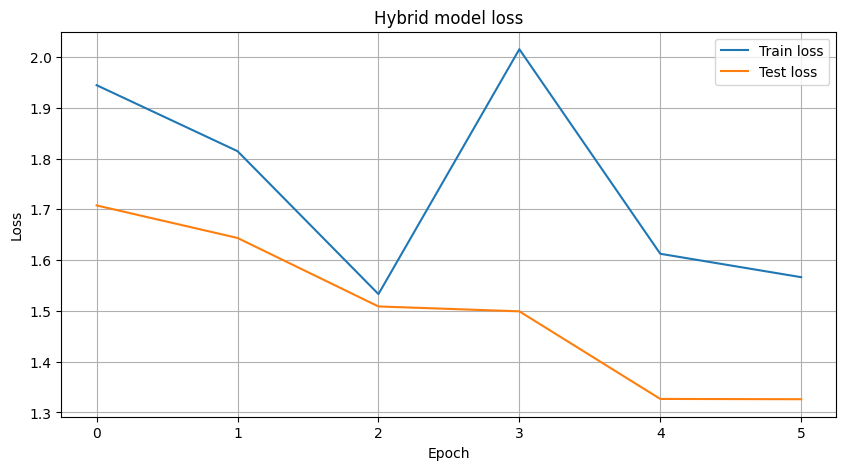

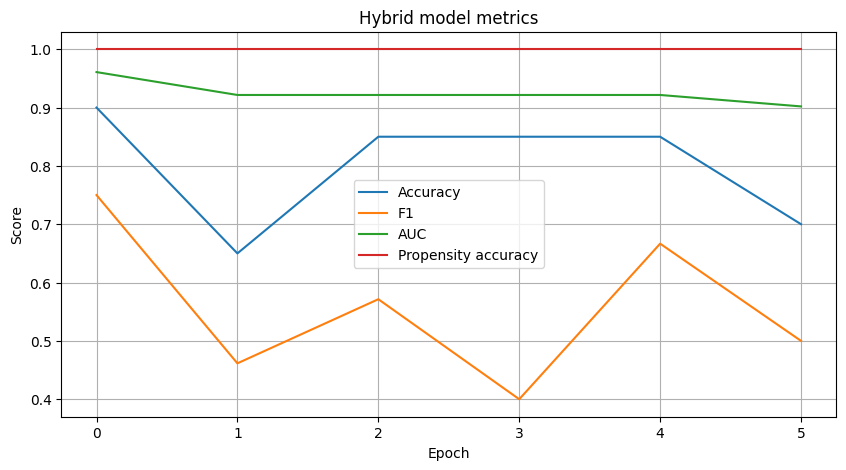

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['test_loss'], label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Hybrid model loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history['test_acc'], label='Accuracy')
plt.plot(history['test_f1'], label='F1')
plt.plot(history['test_auc'], label='AUC')
plt.plot(history['propensity_acc'], label='Propensity accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Hybrid model metrics')
plt.legend()
plt.grid(True)
plt.show()

## 12. Counterfactual what-if prediction

In [29]:
def predict_hybrid_what_if(model, patient_x, patient_mask, treatment_ids):
    """
    Replace every real timestep with a simulated treatment id and return:
    - main transformer mortality risk
    - treatment-specific head risk

    This is model-based what-if prediction, not guaranteed causal effect.
    """
    model.eval()

    x_tensor = torch.tensor(
        patient_x,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    mask_tensor = torch.tensor(
        patient_mask,
        dtype=torch.bool
    ).unsqueeze(0).to(device)

    results = {}

    with torch.no_grad():
        for treatment_id in treatment_ids:
            t_seq = torch.full(
                (1, x_tensor.shape[1]),
                int(treatment_id),
                dtype=torch.long
            ).to(device)

            t_seq = torch.where(
                mask_tensor,
                t_seq,
                torch.full_like(t_seq, PAD_TREATMENT_ID)
            )

            mortality_logit, treatment_logits, propensity_logits, _ = model(
                x_tensor,
                t_seq,
                mask_tensor
            )

            main_risk = torch.sigmoid(mortality_logit).item()
            head_risk = torch.sigmoid(
                treatment_logits[:, int(treatment_id)]
            ).item()

            propensity_prob = torch.softmax(
                propensity_logits,
                dim=1
            )[0, int(treatment_id)].item()

            results[int(treatment_id)] = {
                'main_transformer_risk': float(main_risk),
                'treatment_head_risk': float(head_risk),
                'propensity_probability': float(propensity_prob)
            }

    return results


sample_idx = 0

patient_x = X_test[sample_idx]
patient_mask = mask_test[sample_idx]

real_treatment_ids = [i for i in range(1, num_treatments)]

results = predict_hybrid_what_if(
    model,
    patient_x,
    patient_mask,
    real_treatment_ids
)

print("Hybrid model-based what-if mortality risk for the same patient:\n")

for k, vals in results.items():
    treatment_name = treatment_mapping.get(k, f"Treatment {k}")

    print(
        f"{treatment_name} | "
        f"Main risk: {vals['main_transformer_risk']:.4f} | "
        f"Treatment-head risk: {vals['treatment_head_risk']:.4f} | "
        f"Propensity: {vals['propensity_probability']:.4f}"
    )

Hybrid model-based what-if mortality risk for the same patient:

INSULIN | Main risk: 0.4762 | Treatment-head risk: 0.5340 | Propensity: 0.2796
NO_PRESCRIPTION | Main risk: 0.4140 | Treatment-head risk: 0.4810 | Propensity: 0.2659
OTHER_DRUG | Main risk: 0.4778 | Treatment-head risk: 0.4698 | Propensity: 0.4437


## 13. Counterfactual summary table and visualization

,Simulated Treatment,Main Transformer Risk,Treatment Head Risk,Propensity Probability,Predicted Outcome
0,OTHER_DRUG,0.4778,0.4698,0.4437,Low Risk
1,NO_PRESCRIPTION,0.4140,0.4810,0.2659,Low Risk
2,INSULIN,0.4762,0.5340,0.2796,High Risk


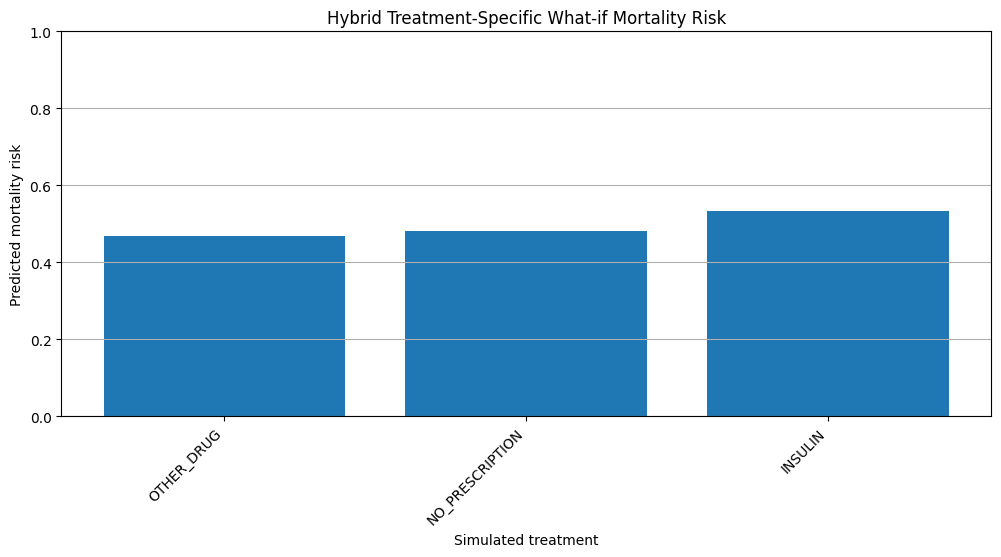

In [30]:
summary_rows = []
for tr, vals in results.items():
    summary_rows.append({
        'Simulated Treatment': treatment_mapping.get(tr, f'Treatment {tr}'),
        'Main Transformer Risk': round(vals['main_transformer_risk'], 4),
        'Treatment Head Risk': round(vals['treatment_head_risk'], 4),
        'Propensity Probability': round(vals['propensity_probability'], 4),
        'Predicted Outcome': 'High Risk' if vals['treatment_head_risk'] >= 0.5 else 'Low Risk'
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by='Treatment Head Risk').reset_index(drop=True)
display(summary_df)

plt.figure(figsize=(12, 5))
plt.bar(summary_df['Simulated Treatment'], summary_df['Treatment Head Risk'])
plt.title('Hybrid Treatment-Specific What-if Mortality Risk')
plt.ylabel('Predicted mortality risk')
plt.xlabel('Simulated treatment')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

## 14. Patient temporal trajectory

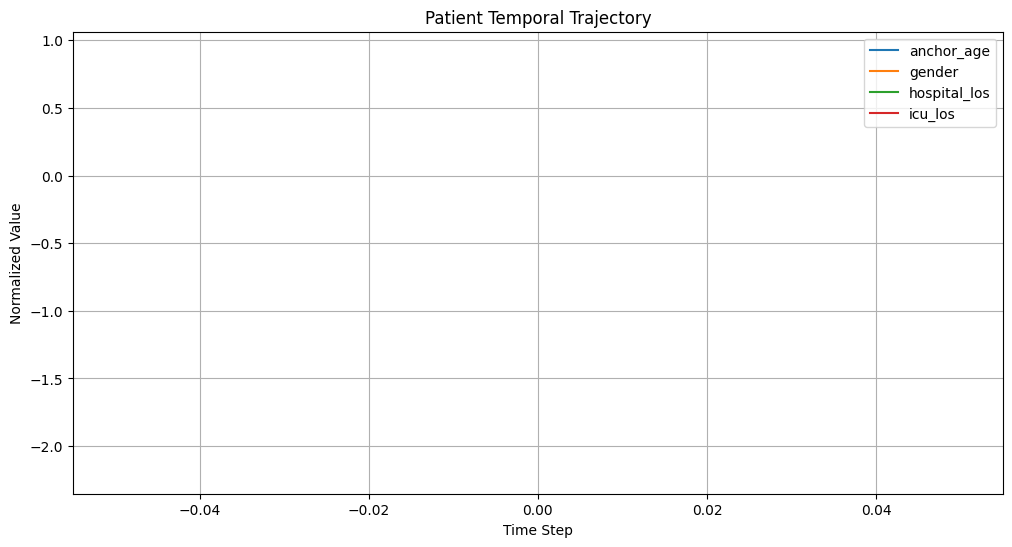

In [31]:
patient_df = pd.DataFrame(patient_x, columns=feature_cols)
valid_idx = patient_mask == 1
patient_df = patient_df[valid_idx]

plt.figure(figsize=(12, 6))
for col in patient_df.columns[:4]:
    plt.plot(patient_df.index, patient_df[col], label=col)

plt.xlabel('Time Step')
plt.ylabel('Normalized Value')
plt.title('Patient Temporal Trajectory')
plt.legend()
plt.grid(True)
plt.show()

## 15. Interpretation notes

- The **main transformer risk** uses the full sequence representation after changing the treatment sequence.
- The **treatment-head risk** is the treatment-specific counterfactual head output.
- The **propensity probability** shows how likely the model thinks that treatment assignment is for the patient.
- A treatment with very low propensity may be less reliable for what-if interpretation because the model saw fewer similar examples.
- This notebook improves modeling logic, but it still does **not** prove clinical causality. For stronger causal claims, add explicit confounding control, inverse propensity weighting, matching, or doubly robust estimation.